# Data unloading and exploration

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw_data/telco_customer_churn.csv")

In [3]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5861,9631-RXVJM,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.25,677.9,No
1858,7517-SAWMO,Female,0,Yes,No,19,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,73.20,1441.1,Yes
4644,5701-ZIKJE,Male,0,No,No,13,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,50.55,610.75,No
3541,1530-ZTDOZ,Female,0,Yes,No,49,No,No phone service,DSL,Yes,...,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75,No
4552,1385-TQOZW,Female,0,No,No,9,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),20.45,147.55,No


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
pd.set_option('display.max_columns', None)      # Show all the columns in DataFrame
pd.set_option('display.max_rows', None)           #  Show all the rows in Dataframe

In [8]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


# Binary Encoding 

In [9]:
# For the ones having 2 categories, we are doing the binary encoding 
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Map Yes/No and M/F to 0/1
df[binary_cols] =  df[binary_cols].replace({
    'Yes':0, 'No':1,
    'Male':0, 'Female':1
})

/tmp/ipykernel_21462/3337150396.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] =  df[binary_cols].replace({


In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,0,1,1,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,0,Electronic check,29.85,29.85,1
1,5575-GNVDE,0,0,1,1,34,0,No,DSL,Yes,No,Yes,No,No,No,One year,1,Mailed check,56.95,1889.5,1
2,3668-QPYBK,0,0,1,1,2,0,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,0,Mailed check,53.85,108.15,0
3,7795-CFOCW,0,0,1,1,45,1,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,1,Bank transfer (automatic),42.30,1840.75,1
4,9237-HQITU,1,0,1,1,2,0,No,Fiber optic,No,No,No,No,No,No,Month-to-month,0,Electronic check,70.70,151.65,0


# One-Hot Encoding

In [11]:
# Categorical columns with more than 2 categories
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
                 , 'Contract', 'PaymentMethod']

# One hot encode
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,0,0,1,1,1,0,29.85,29.85,1,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,0,0,1,1,34,0,1,56.95,1889.5,1,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,0,0,1,1,2,0,0,53.85,108.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,0,0,1,1,45,1,1,42.30,1840.75,1,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,1,0,1,1,2,0,0,70.70,151.65,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


# Cleaning

In [13]:
# Converting string to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
# This one is not needed 
df = df.drop('customerID', axis=1)

In [15]:
# Turning bool to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

# Data visulalisation

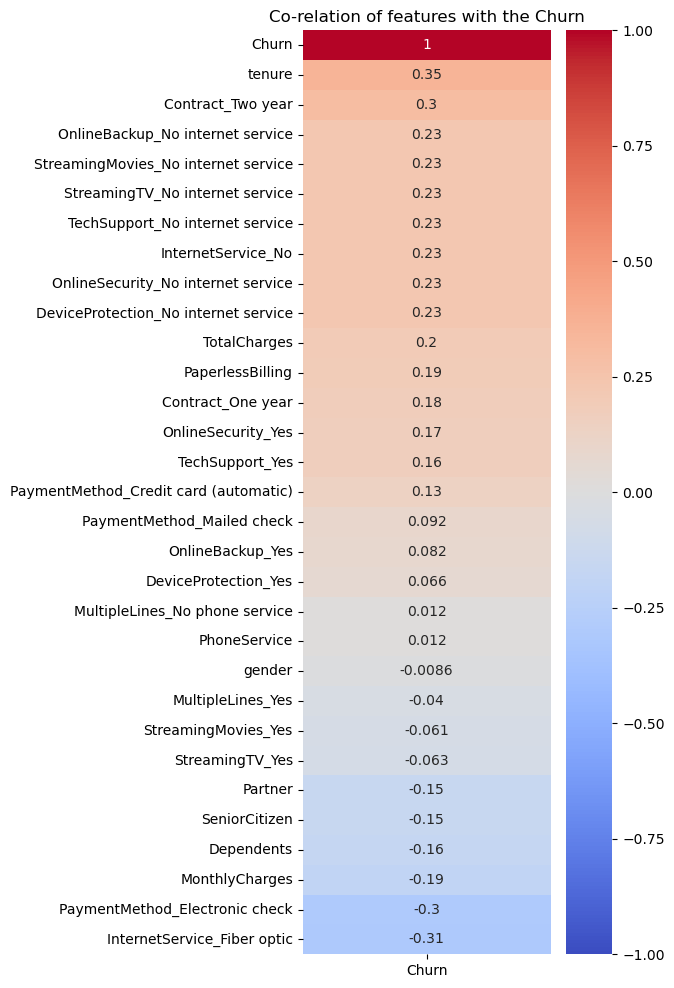

In [17]:
# Compute the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with the Churn 
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# plot the heat-map
plt.figure(figsize=(4,12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Co-relation of features with the Churn')
plt.show()

# Look for the mulit-collinearity

In [18]:
# We need to collapse redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [19]:
# Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [20]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

/home/codebind/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature        VIF
24                       No_phone_service        inf
5                            PhoneService        inf
23                    No_internet_service        inf
11                     InternetService_No        inf
7                          MonthlyCharges  52.874217
8                            TotalCharges  21.640210
4                                  tenure  20.696884
10            InternetService_Fiber optic   9.933123
3                              Dependents   4.623674
19                      Contract_Two year   3.488117
17                    StreamingMovies_Yes   3.479772
16                        StreamingTV_Yes   3.465808
2                                 Partner   3.031967
21         PaymentMethod_Electronic check   2.970118
9                       MultipleLines_Yes   2.777983
14                   DeviceProtection_Yes   2.551309
13                       OnlineBackup_Yes   2.489566
15                        TechSupport_Yes   2.

In [21]:
"""
Hence, if the VIF is above 6 or 7, it means they multicollinearity, which will make the prediction unstable
We just use the tree-based model for it, since it is less sensitive to this.
"""

'\nHence, if the VIF is above 6 or 7, it means they multicollinearity, which will make the prediction unstable\nWe just use the tree-based model for it, since it is less sensitive to this.\n'

### More focus is on recall in terms of business perspective as to avoid churn for as much as possible customers....

# Modeling 

In [22]:
# Importing required classses and librarie
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import time
import pandas as pd

# Prepare data 
X = df.drop(columns=['Churn'])
y = df['Churn']

# First split off test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# splitting the remaining 80% into train (75%) and val (25%)
# gives the 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# lower than 0.5 to boost the recall 
THRESHOLD = 0.3

Train: (4225, 25), Val: (1409, 25), Test: (1409, 25)


# Random Forest

In [23]:
# Train
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=4,
                             max_features='sqrt', class_weight='balanced_subsample',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate on all three splits
for name, X_s, y_s in [("TRAIN", X_train, y_train), ("VAL", X_val, y_val), ("TEST", X_test, y_test)]:
    preds = (rf.predict_proba(X_s)[:, 1] >= THRESHOLD).astype(int)
    print(f"-> {name} <-")
    print(classification_report(y_s, preds, digits=3))

-> TRAIN <-
              precision    recall  f1-score   support

           0      0.736     0.587     0.653      1121
           1      0.861     0.924     0.891      3104

    accuracy                          0.835      4225
   macro avg      0.799     0.755     0.772      4225
weighted avg      0.828     0.835     0.828      4225

-> VAL <-
              precision    recall  f1-score   support

           0      0.662     0.513     0.578       374
           1      0.837     0.905     0.870      1035

    accuracy                          0.801      1409
   macro avg      0.750     0.709     0.724      1409
weighted avg      0.791     0.801     0.793      1409

-> TEST <-
              precision    recall  f1-score   support

           0      0.680     0.471     0.556       374
           1      0.828     0.920     0.871      1035

    accuracy                          0.801      1409
   macro avg      0.754     0.695     0.714      1409
weighted avg      0.788     0.801     0.7

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.805   0.939   0.867   
0.3     0.828   0.920   0.871   
0.35    0.846   0.879   0.862   
0.4     0.860   0.845   0.853   
0.45    0.874   0.820   0.846   
0.5     0.889   0.786   0.834   


### Able to capture 92.1 percent of actual churners with Random Forest.

# LightGBM Classifier

In [25]:
from lightgbm import LGBMClassifier
import time

lgbm = LGBMClassifier(
    n_estimators=500,           # set high, let early stopping decide
    learning_rate=0.05,
    class_weight='balanced',
    num_leaves=31,               # default, controls complexity
    min_child_samples=20,        # min samples per leaf, regularization
    n_jobs=-1,
    random_state=42
)

start_train = time.time()
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=100)   # print every 100 iters
    ]
)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f}s | Best iteration: {lgbm.best_iteration_}")

# Evaluate on all three splits
start_pred = time.time()
for name, X_s, y_s in [("TRAIN", X_train, y_train), ("VAL", X_val, y_val), ("TEST", X_test, y_test)]:
    preds = (lgbm.predict_proba(X_s)[:, 1] >= THRESHOLD).astype(int)
    print(f"\n--- {name} ---")
    print(classification_report(y_s, preds, digits=3))
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f}s")

# Threshold tuning on val set
from sklearn.metrics import precision_score, recall_score, f1_score

proba_val = lgbm.predict_proba(X_val)[:, 1]
print(f"\n{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba_val >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec  = recall_score(y_val, preds, pos_label=1)
    f1   = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8.2f}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3104, number of negative: 1121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 25
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 30 rounds
[100]	training's binary_logloss: 0.349221	valid_1's binary_logloss: 0.47001
Early stopping, best iteration is:
[133]	training's binary_logloss: 0.320757	valid_1's binary_logloss: 0.467243
Training time: 1.90s | Best iteration: 

In [26]:
# Threshold tuning on val set
from sklearn.metrics import precision_score, recall_score, f1_score

proba_val = lgbm.predict_proba(X_val)[:, 1]
print(f"\n{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba_val >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec  = recall_score(y_val, preds, pos_label=1)
    f1   = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8.2f}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")


Thresh  Prec_1  Rec_1   F1_1    
0.25    0.829   0.908   0.867   
0.30    0.847   0.885   0.866   
0.35    0.864   0.860   0.862   
0.40    0.869   0.842   0.855   
0.45    0.876   0.809   0.841   
0.50    0.894   0.783   0.835   


### Now able to capture 88.88 percent of actual churners with LightGBM but too slow.

# XGBoost Classifier

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=696,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.5,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Training
start_train = time.time()
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],  
    verbose=100
)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f}s")

# Evaluate on all three splits
start_test = time.time()
for name, X_s, y_s in [("TRAIN", X_train, y_train), ("VAL", X_val, y_val), ("TEST", X_test, y_test)]:
    preds = (xgb.predict_proba(X_s)[:, 1] >= THRESHOLD).astype(int)
    print(f"\n--- {name} ---")
    print(classification_report(y_s, preds, digits=3))
test_time = time.time() - start_test
print(f"Prediction time: {test_time:.2f}s")

[0]	validation_0-logloss:0.69000	validation_1-logloss:0.68996
[100]	validation_0-logloss:0.53284	validation_1-logloss:0.53610
[200]	validation_0-logloss:0.48638	validation_1-logloss:0.49601
[300]	validation_0-logloss:0.46601	validation_1-logloss:0.48186
[400]	validation_0-logloss:0.45484	validation_1-logloss:0.47663
[500]	validation_0-logloss:0.44761	validation_1-logloss:0.47466
[600]	validation_0-logloss:0.44146	validation_1-logloss:0.47349
[695]	validation_0-logloss:0.43638	validation_1-logloss:0.47237
Training time: 5.11s

--- TRAIN ---
              precision    recall  f1-score   support

           0      0.698     0.615     0.654      1121
           1      0.867     0.904     0.885      3104

    accuracy                          0.827      4225
   macro avg      0.782     0.759     0.769      4225
weighted avg      0.822     0.827     0.824      4225


--- VAL ---
              precision    recall  f1-score   support

           0      0.645     0.583     0.612       374
     

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba_val = xgb.predict_proba(X_val)[:, 1]

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba_val >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec  = recall_score(y_val, preds, pos_label=1)
    f1   = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8.2f}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Thresh  Prec_1  Rec_1   F1_1    
0.25    0.833   0.905   0.868   
0.30    0.854   0.884   0.869   
0.35    0.869   0.861   0.865   
0.40    0.883   0.829   0.855   
0.45    0.889   0.790   0.837   
0.50    0.900   0.754   0.820   


In [29]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
import time

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

start_train = time.time()
ensemble.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f}s")

# Evaluate on all three splits
start_pred = time.time()
for name, X_s, y_s in [("TRAIN", X_train, y_train), ("VAL", X_val, y_val), ("TEST", X_test, y_test)]:
    preds = (ensemble.predict_proba(X_s)[:, 1] >= THRESHOLD).astype(int)
    print(f"\n--- {name} ---")
    print(classification_report(y_s, preds, digits=3))
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f}s")

# Threshold tuning on val set
from sklearn.metrics import precision_score, recall_score, f1_score

proba_val = ensemble.predict_proba(X_val)[:, 1]
print(f"\n{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba_val >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec  = recall_score(y_val, preds, pos_label=1)
    f1   = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8.2f}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3104, number of negative: 1121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 14.45s

--- TRAIN ---
              precision    recall  f1-score   support

           0      0.820     0.682     0.745      1121
           1      0.892     0.946     0.918      3104

    accuracy                          0.876      4225
   macro avg      0.856     0.814     0.831      4225
weighted avg      0.873     0.876     0.872      4225


---

# Hyperparameter tuning(optuna) and experiment tracking(MLflow)

In [32]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs":-1,
        "scale_pos_weight": (y_train == 0).sum()/ (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)   # Keep the threshold tuned
    return recall_score(y_test, y_pred, pos_label=1)    # optimize the recall for churners

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params", study.best_params)
print("Best Recall", study.best_value)

[I 2026-05-23 16:31:45,096] A new study created in memory with name: no-name-d73a5d1e-0842-4765-8276-d24f788803e9
[I 2026-05-23 16:31:46,261] Trial 0 finished with value: 0.8840579710144928 and parameters: {'n_estimators': 541, 'learning_rate': 0.19971200550341084, 'max_depth': 6, 'subsample': 0.9754657078617975, 'colsample_bytree': 0.788161038493763, 'min_child_weight': 8, 'gamma': 4.271049527292616, 'reg_alpha': 1.584960919875349, 'reg_lambda': 3.9367299101006905}. Best is trial 0 with value: 0.8840579710144928.
[I 2026-05-23 16:31:47,106] Trial 1 finished with value: 0.885024154589372 and parameters: {'n_estimators': 580, 'learning_rate': 0.1975644351980675, 'max_depth': 8, 'subsample': 0.9804786974214688, 'colsample_bytree': 0.6429318207478444, 'min_child_weight': 9, 'gamma': 1.321112369877226, 'reg_alpha': 2.8972039955753557, 'reg_lambda': 0.31305158502469344}. Best is trial 1 with value: 0.885024154589372.
[I 2026-05-23 16:31:47,854] Trial 2 finished with value: 0.883091787439613

Best Params {'n_estimators': 600, 'learning_rate': 0.012326309938493573, 'max_depth': 3, 'subsample': 0.9998890790164399, 'colsample_bytree': 0.7916453603192284, 'min_child_weight': 9, 'gamma': 4.982385648061852, 'reg_alpha': 0.7270710214354863, 'reg_lambda': 4.268433508843633}
Best Recall 0.9024154589371981


In [33]:
best_params = study.best_params

xgb_tuned = XGBClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
xgb_tuned.fit(X_train, y_train)

for name, X_s, y_s in [("TRAIN", X_train, y_train), ("VAL", X_val, y_val), ("TEST", X_test, y_test)]:
    preds = (xgb_tuned.predict_proba(X_s)[:, 1] >= THRESHOLD).astype(int)
    print(f"\n--- {name} ---")
    print(classification_report(y_s, preds, digits=3))


--- TRAIN ---
              precision    recall  f1-score   support

           0      0.857     0.171     0.286      1121
           1      0.768     0.990     0.865      3104

    accuracy                          0.773      4225
   macro avg      0.812     0.580     0.575      4225
weighted avg      0.792     0.773     0.711      4225


--- VAL ---
              precision    recall  f1-score   support

           0      0.862     0.150     0.255       374
           1      0.763     0.991     0.863      1035

    accuracy                          0.768      1409
   macro avg      0.812     0.571     0.559      1409
weighted avg      0.789     0.768     0.701      1409


--- TEST ---
              precision    recall  f1-score   support

           0      0.757     0.142     0.239       374
           1      0.760     0.984     0.858      1035

    accuracy                          0.760      1409
   macro avg      0.759     0.563     0.548      1409
weighted avg      0.759     0.76

In [35]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    
    recall_1 = recall_score(y_val, y_pred, pos_label=1)  # churner recall
    recall_0 = recall_score(y_val, y_pred, pos_label=0)  # non-churner recall
    
    # Maximize churn recall BUT only if Class 0 recall stays above 40%
    if recall_0 < 0.40:
        return 0  # penalize models that completely ignore non-churners
    
    return recall_1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

[I 2026-05-23 16:41:10,803] A new study created in memory with name: no-name-77ed2899-d64d-4960-93eb-5577fd31820f
[I 2026-05-23 16:41:12,821] Trial 0 finished with value: 0.8821256038647343 and parameters: {'n_estimators': 627, 'learning_rate': 0.06340517915999616, 'max_depth': 6, 'subsample': 0.8373216647746584, 'colsample_bytree': 0.7818166994493488, 'min_child_weight': 3, 'gamma': 0.4704275071579528, 'reg_alpha': 0.4403615260322913, 'reg_lambda': 0.4718312499776711}. Best is trial 0 with value: 0.8821256038647343.
[I 2026-05-23 16:41:13,915] Trial 1 finished with value: 0.8879227053140096 and parameters: {'n_estimators': 431, 'learning_rate': 0.05175640397185044, 'max_depth': 10, 'subsample': 0.8601500289299502, 'colsample_bytree': 0.7155893647714059, 'min_child_weight': 1, 'gamma': 2.020369753633232, 'reg_alpha': 4.174897708988766, 'reg_lambda': 0.8169128732952313}. Best is trial 1 with value: 0.8879227053140096.
[I 2026-05-23 16:41:14,449] Trial 2 finished with value: 0.8917874396

In [37]:
import pandas as pd
import time
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, recall_score, precision_score

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=4,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=696,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.5,
        min_child_weight=5,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=133,          # your best_iteration
        learning_rate=0.05,
        class_weight='balanced',
        num_leaves=31,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    # Train time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # Predict time
    start = time.time()
    proba = model.predict_proba(X_test)[:, 1]
    pred_time = time.time() - start

    preds = (proba >= THRESHOLD).astype(int)

    results.append({
        "Model": name,
        "Train Time (s)": round(train_time, 3),
        "Pred Time (s)": round(pred_time, 4),
        "Accuracy": round((preds == y_test).mean(), 3),
        "Class 1 Recall": round(recall_score(y_test, preds, pos_label=1), 3),
        "Class 0 Recall": round(recall_score(y_test, preds, pos_label=0), 3),
        "Class 1 F1": round(f1_score(y_test, preds, pos_label=1), 3),
        "Macro F1": round(f1_score(y_test, preds, average='macro'), 3),
    })

df_results = pd.DataFrame(results).set_index("Model")
print(df_results.to_string())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3104, number of negative: 1121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
               Train Time (s)  Pred Time (s)  Accuracy  Class 1 Recall  Class 0 Recall  Class 1 F1  Macro F1
Model                                                                                                       
Random Forest           2.181         0.0972     0.801           0.920           0.471       0.871     0.714
XGBoost                 2.010         0.0

## From the above results I came to conclusion that XGBoost has fastest training time and almost as good as LightGBM accuracy hence choice of model is XGBoost.